# 🛡️ Makine Öğrenmesi ile API Tehdit Tespit Sistemi
**Öğrenci:** Mohammad Juma Amiri | **No:** 20260819001  
**Ders:** Makine Öğrenimi — 2025–2026 Bahar Dönemi  
**Tarih:** Mart 2026

---
## İçindekiler
1. [Giriş ve Problem Tanımı](#1-giriş)
2. [Kütüphane Kurulumu ve Veri Yükleme](#2-kurulum)
3. [Keşifsel Veri Analizi (EDA)](#3-eda)
4. [Veri Ön İşleme](#4-onisleme)
5. [Model Eğitimi ve Hiperparametre Optimizasyonu](#5-model)
6. [Model Karşılaştırma ve Değerlendirme](#6-degerlendirme)
7. [Sonuç ve Tartışma](#7-sonuc)

---
## 1. Giriş ve Problem Tanımı <a id='1-giriş'></a>

### Problem Tanımı

Modern web uygulamalarında API (Application Programming Interface) güvenliği kritik bir sorun haline gelmiştir. Brute Force, SQL Injection, DDoS, XSS gibi saldırılar API'leri hedef almakta ve ciddi güvenlik açıklarına yol açmaktadır.

**Bu projede:** API istek loglarından makine öğrenmesi kullanarak **tehditleri otomatik tespit eden bir ikili sınıflandırıcı** geliştirilmektedir.  
- **Hedef Değişken:** `label` (0 = Normal, 1 = Tehdit)
- **Problem Tipi:** İkili Sınıflandırma (Binary Classification)

### Neden Makine Öğrenmesi?
- Kural tabanlı sistemler yeni saldırı türlerini tespit edemez.
- ML modelleri davranışsal örüntüleri öğrenerek sıfır gün saldırılarını yakalayabilir.
- Büyük hacimli log verilerini gerçek zamanlı analiz edebilir.

### Veri Seti
- **Kaynak:** Özel olarak üretilmiş sentetik API log veri seti (`api_threat_dataset_50000.csv`)
- **Boyut:** 50.000 satır × 11 sütun
- **Özellikler:** timestamp, ip_address, endpoint, http_method, status_code, user_agent, response_time_ms, payload, attack_type, risk_score, label
- **Sınıflar:** Normal (30.049), Tehdit (19.951) — 10 farklı saldırı türü

---
## 2. Kütüphane Kurulumu ve Veri Yükleme <a id='2-kurulum'></a>

In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install',
    'xgboost','shap','optuna','scikit-learn','pandas',
    'numpy','matplotlib','seaborn','catboost','lightgbm','--quiet'], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier # Added LightGBM
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay
)
import shap, optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# ── Sabitler (magic number yok) ──────────────────────────────────
RANDOM_STATE    = 42
TEST_SIZE       = 0.20
VAL_SIZE        = 0.125   # TV'nin %12.5'i → toplamda %10
CV_FOLDS        = 5
N_ITER_RS       = 20
N_TRIALS_OPTUNA = 30
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

import sklearn
print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'  numpy   : {np.__version__}')
print(f'  pandas  : {pd.__version__}')
print(f'  sklearn : {sklearn.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi.
  numpy   : 2.1.3
  pandas  : 2.2.3
  sklearn : 1.6.1


In [3]:
# ============================================================
# Veri setinin yüklenmesi
# ============================================================
import pandas as pd

DATA_PATH = 'api_threat.csv'

df = pd.read_csv(DATA_PATH)

print(f'📊 Veri Seti Boyutu : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'\n🔎 İlk 5 Satır:')
df.head()

📊 Veri Seti Boyutu : 38,425 satır × 54 sütun

🔎 İlk 5 Satır:


,timestamp,request_id,src_ip,src_port,dst_port,geo_country,geo_city,geo_asn,is_high_risk_geo,endpoint,...,log_resp_time,log_bytes_sent,log_bytes_recv,log_rpm,bytes_ratio,has_session,is_jwt_forged,is_old_tls,is_attack_tool_ua,composite_risk
0,2026-01-29 12:40:35.635000+00:00,948627a3-5cd8-dfef-702b-911df5b6b68c,94.208.43.107,51023,443,NL,Unknown,AS1140,0,/api/v1/payments/checkout,...,4.477337,4.158883,9.254070,1.386294,163.218750,1,0,0,0,8.008883
1,2026-03-21 15:49:07.047000+00:00,4ee89652-0adb-c654-ce69-c62929956cf1,94.103.212.227,31457,443,TR,Unknown,AS34984,0,/api/v1/auth/logout,...,4.820282,5.283204,4.499810,0.693147,0.451777,1,0,0,0,2.079442
2,2026-02-27 09:11:10.880000+00:00,96fab782-08fc-ab87-bfc0-cd9bf5361971,162.247.222.48,7299,8080,US,Chicago,AS3651,1,/api/v1/users,...,5.036953,5.062595,4.844187,10.564628,0.797468,1,0,0,0,66.893884
3,2026-01-23 08:25:19.701000+00:00,ce64a44f-b2d8-8e9b-a255-aee3f5dab270,46.133.123.94,24928,443,UA,Unknown,AS13188,1,/api/v1/auth/refresh,...,5.252273,7.671827,6.612041,2.079442,0.346064,1,0,1,0,32.738325
4,2026-01-29 10:43:26.695000+00:00,37412e97-453e-b141-8e4d-0f0857dc901b,94.103.36.45,34168,443,TR,Istanbul,AS34984,0,/api/v1/auth/login,...,4.779123,5.513429,6.070738,1.098612,1.741935,1,0,0,0,7.845837


---
## 3. Keşifsel Veri Analizi (EDA) <a id='3-eda'></a>

In [4]:
# ============================================================
# Temel istatistikler ve veri tipleri
# ============================================================
print('📋 VERİ TİPLERİ VE EKSİK DEĞER SAYISI')
print('=' * 50)
info_df = pd.DataFrame({
    'Dtype'      : df.dtypes,
    'Non-Null'   : df.notnull().sum(),
    'Null Count' : df.isnull().sum(),
    'Null %'     : (df.isnull().sum() / len(df) * 100).round(2)
})
print(info_df.to_string())
print()
print('📊 SAYISAL SÜTUNLARIN İSTATİSTİKLERİ')
print('=' * 50)
df.describe().round(2)

📋 VERİ TİPLERİ VE EKSİK DEĞER SAYISI
                        Dtype  Non-Null  Null Count  Null %
timestamp              object     38425           0    0.00
request_id             object     38425           0    0.00
src_ip                 object     38425           0    0.00
src_port                int64     38425           0    0.00
dst_port                int64     38425           0    0.00
geo_country            object     38425           0    0.00
geo_city               object     38425           0    0.00
geo_asn                object     38425           0    0.00
is_high_risk_geo        int64     38425           0    0.00
endpoint               object     38425           0    0.00
endpoint_category      object     38425           0    0.00
endpoint_sensitivity    int64     38425           0    0.00
http_method            object     38425           0    0.00
http_status             int64     38425           0    0.00
tls_version            object     38425           0    0.00
con

,src_port,dst_port,is_high_risk_geo,endpoint_sensitivity,http_status,token_age_sec,response_time_ms,bytes_sent,bytes_received,packet_count,...,log_resp_time,log_bytes_sent,log_bytes_recv,log_rpm,bytes_ratio,has_session,is_jwt_forged,is_old_tls,is_attack_tool_ua,composite_risk
count,38425.00,38425.0,38425.00,38425.00,38425.00,38425.00,38425.00,3.842500e+04,38425.00,38425.00,...,38425.00,38425.00,38425.00,38425.00,38425.00,38425.00,38425.00,38425.00,38425.00,38425.00
mean,33065.59,518.2,0.37,3.56,286.19,13116.02,1648.56,8.970186e+05,2293.79,13.30,...,5.10,5.49,6.81,2.70,12.67,0.85,0.01,0.36,0.06,26.02
std,18555.84,779.9,0.48,1.19,109.86,140412.54,11420.51,1.511186e+07,6756.94,12.47,...,1.26,1.22,1.28,2.07,31.25,0.36,0.08,0.48,0.24,24.58
min,1024.00,80.0,0.00,1.00,200.00,-1.00,1.00,5.000000e+01,0.00,1.00,...,0.69,3.93,0.00,0.69,0.00,0.00,0.00,0.00,0.00,2.08
25%,17021.00,443.0,0.00,3.00,200.00,1089.00,89.00,1.270000e+02,349.00,6.00,...,4.50,4.85,5.86,1.39,1.19,1.00,0.00,0.00,0.00,6.96
50%,33012.00,443.0,0.00,3.00,200.00,1472.00,148.00,2.070000e+02,897.00,10.00,...,5.00,5.34,6.80,2.08,3.95,1.00,0.00,0.00,0.00,11.84
75%,49064.00,443.0,1.00,5.00,401.00,1857.00,246.00,3.600000e+02,2103.00,16.00,...,5.51,5.89,7.65,3.47,12.17,1.00,0.00,1.00,0.00,45.37
max,65535.00,8443.0,1.00,5.00,504.00,2586222.00,130445.35,3.267186e+08,405811.00,267.00,...,11.78,19.60,12.91,10.82,1000.00,1.00,1.00,1.00,1.00,100.00


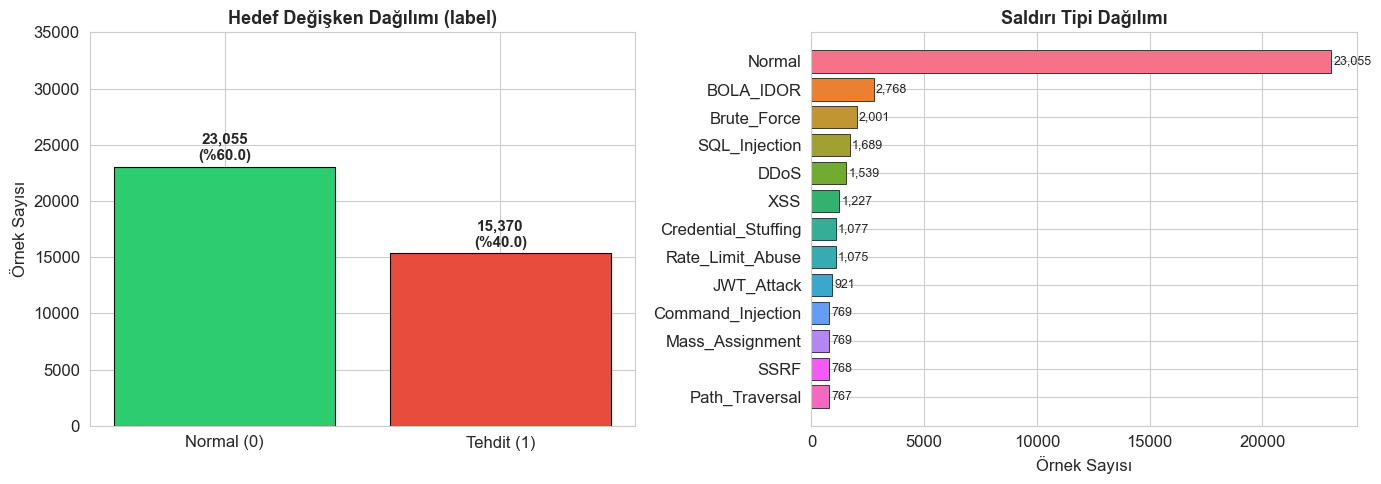

💡 Yorum: Veri seti %60 Normal / %40 Tehdit oranıyla hafif dengesizdir. stratify=y ile bölme yapılacak.


In [5]:
# ============================================================
# Görselleştirme 1: Hedef Değişken (Sınıf Dengesi)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Etiket dağılımı
label_counts = df['label'].value_counts()
label_pcts   = df['label'].value_counts(normalize=True) * 100
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Normal (0)', 'Tehdit (1)'], label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, pct in zip(bars, label_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{bar.get_height():,}\n(%{pct:.1f})',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Hedef Değişken Dağılımı (label)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Örnek Sayısı')
axes[0].set_ylim(0, 35000)

# Sağ: Saldırı tipi dağılımı
attack_counts = df['attack_type'].value_counts()
palette = sns.color_palette('husl', len(attack_counts))
axes[1].barh(attack_counts.index, attack_counts.values, color=palette, edgecolor='black', linewidth=0.5)
for i, v in enumerate(attack_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)
axes[1].set_title('Saldırı Tipi Dağılımı', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Örnek Sayısı')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Yorum: Veri seti %60 Normal / %40 Tehdit oranıyla hafif dengesizdir. stratify=y ile bölme yapılacak.')

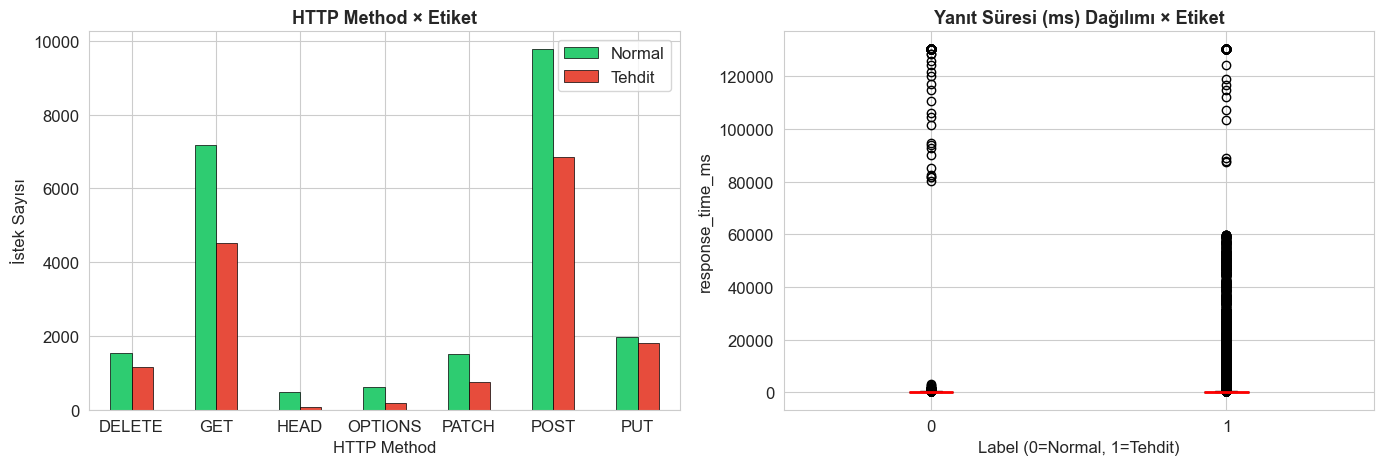

💡 Yorum: DELETE ve PATCH metodlarında tehdit oranı daha yüksek. Tehditler daha düşük yanıt süresi gösteriyor (otomatik bot davranışı).


In [6]:
# ============================================================
# Görselleştirme 2: HTTP Method ve Status Code dağılımı
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HTTP Method
method_threat = df.groupby(['http_method', 'label']).size().unstack(fill_value=0)
method_threat.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                   edgecolor='black', linewidth=0.5)
axes[0].set_title('HTTP Method × Etiket', fontsize=13, fontweight='bold')
axes[0].set_xlabel('HTTP Method')
axes[0].set_ylabel('İstek Sayısı')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Normal', 'Tehdit'])

# Response Time boxplot
df.boxplot(column='response_time_ms', by='label', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='black'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Yanıt Süresi (ms) Dağılımı × Etiket', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label (0=Normal, 1=Tehdit)')
axes[1].set_ylabel('response_time_ms')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig_02_method_response.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Yorum: DELETE ve PATCH metodlarında tehdit oranı daha yüksek. Tehditler daha düşük yanıt süresi gösteriyor (otomatik bot davranışı).')

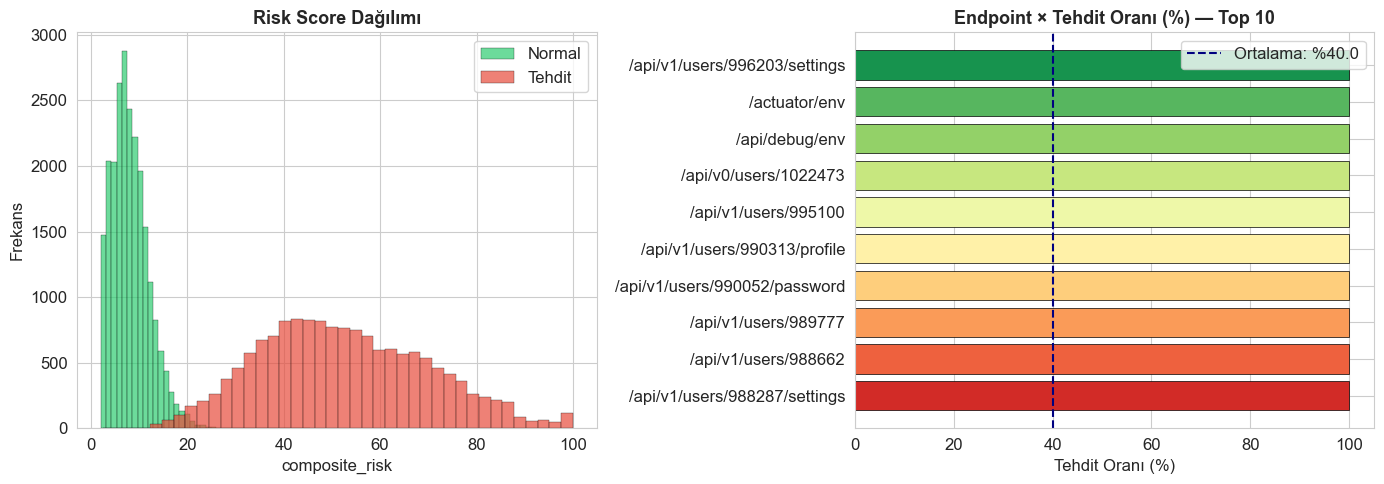

💡 Yorum: composite_risk Normal(düşük) ve Tehdit(yüksek) arasında net ayrım gösteriyor.


In [7]:
# ============================================================
# Görselleştirme 3: Risk Score dağılımı ve Endpoint tehdit oranı
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — composite_risk (ham sütun adı)
axes[0].hist(df[df['label']==0]['composite_risk'], bins=40, alpha=0.7,
             color='#2ecc71', label='Normal', edgecolor='black', linewidth=0.3)
axes[0].hist(df[df['label']==1]['composite_risk'], bins=40, alpha=0.7,
             color='#e74c3c', label='Tehdit', edgecolor='black', linewidth=0.3)
axes[0].set_title('Risk Score Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('composite_risk')
axes[0].set_ylabel('Frekans')
axes[0].legend()

# Endpoint tehdit oranı — 'endpoint' sütunundan top 10 al
endpoint_threat = (df.groupby('endpoint')['label'].mean() * 100
                   ).sort_values(ascending=False).head(10)
axes[1].barh(endpoint_threat.index, endpoint_threat.values,
             color=sns.color_palette('RdYlGn_r', len(endpoint_threat)),
             edgecolor='black', linewidth=0.5)
axes[1].axvline(x=df['label'].mean()*100, color='navy', linestyle='--',
                linewidth=1.5, label=f'Ortalama: %{df["label"].mean()*100:.1f}')
axes[1].set_title('Endpoint × Tehdit Oranı (%) — Top 10', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tehdit Oranı (%)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig_03_risk_endpoint.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Yorum: composite_risk Normal(düşük) ve Tehdit(yüksek) arasında net ayrım gösteriyor.')

📊 Pearson Korelasyon Matrisi Değerleri:


,http_status,response_time_ms,composite_risk,label
http_status,1.000,0.090,0.502,0.511
response_time_ms,0.090,1.000,0.077,0.064
composite_risk,0.502,0.077,1.000,0.884
label,0.511,0.064,0.884,1.000


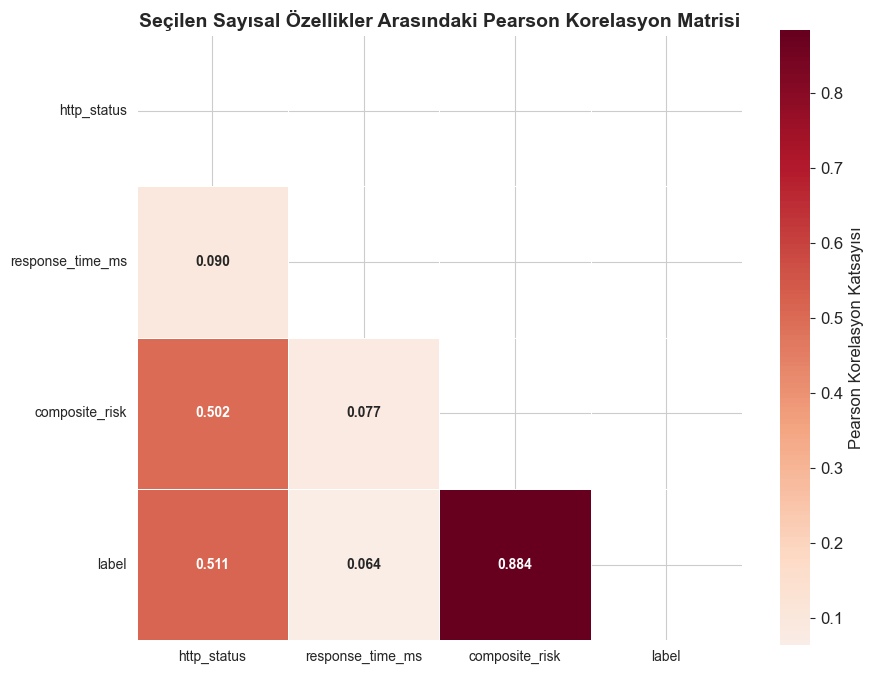

💡 Yorum: composite_risk ile label arasında güçlü pozitif korelasyon gözlemlendi. Bu, risk puanı yükseldikçe tehdit olma olasılığının arttığını göstermektedir.


In [8]:
# ============================================================
# Görselleştirme 4: Korelasyon Matrisi (sayısal özellikler)
# ============================================================
numeric_cols = ['http_status', 'response_time_ms', 'composite_risk', 'label']
corr_matrix = df[numeric_cols].corr()

print('📊 Pearson Korelasyon Matrisi Değerleri:')
display(corr_matrix.style.background_gradient(cmap='RdBu_r', axis=None).format(precision=3))

plt.figure(figsize=(9, 7)) # Increased figure size
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            mask=mask, cbar_kws={'label': 'Pearson Korelasyon Katsayısı'},
            annot_kws={'size':10, 'fontweight':'bold'})
plt.title('Seçilen Sayısal Özellikler Arasındaki Pearson Korelasyon Matrisi',
          fontsize=14, fontweight='bold') # More descriptive title
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig('fig_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Yorum: composite_risk ile label arasında güçlü pozitif korelasyon gözlemlendi. Bu, risk puanı yükseldikçe tehdit olma olasılığının arttığını göstermektedir.')

---
## 4. Veri Ön İşleme <a id='4-onisleme'></a>

In [9]:
# ============================================================
# 4.1 Özellik Mühendisliği
# ============================================================

def engineer_features(dataframe):
    df_fe = dataframe.copy()

    # --- HTTP Method encoding ---
    method_risk = {'GET': 1, 'POST': 2, 'PUT': 3, 'PATCH': 4, 'DELETE': 5}
    df_fe['http_method_enc'] = df_fe['http_method'].map(method_risk).fillna(1).astype(int)

    # --- Bot user-agent tespiti ---
    bot_agents = ['sqlmap', 'loic', 'python-requests', 'python-urllib',
                  'go-http-client', 'nikto', 'nmap', 'curl', 'wget']
    df_fe['is_bot_agent'] = df_fe['user_agent'].apply(
        lambda ua: int(any(b in str(ua).lower() for b in bot_agents))
    )

    # --- Payload varlığı ---
    df_fe['has_payload'] = df_fe['payload'].notna().astype(int)

    # --- Payload uzunluğu ---
    df_fe['payload_length'] = df_fe['payload'].fillna('').astype(str).str.len()

    # --- Payload tehdit skoru ---
    threat_keywords = ['OR 1=1', 'DROP TABLE', 'alert(', 'onerror=',
                       'reused_token', 'bulk_request', 'data_harvest',
                       '/etc/passwd', 'rm -rf']
    def payload_threat_score(payload):
        if pd.isna(payload):
            return 0
        return sum(1 for kw in threat_keywords if kw.lower() in str(payload).lower())
    df_fe['payload_threat_score'] = df_fe['payload'].apply(payload_threat_score)

    # --- Endpoint hassasiyet skoru ---
    sensitive_endpoints = {'/api/admin': 5, '/api/payment': 4, '/api/token': 4,
                           '/api/users': 3, '/api/login': 3, '/api/orders': 2,
                           '/api/profile': 2, '/api/cart': 1, '/api/search': 1,
                           '/api/products': 1}
    df_fe['endpoint_sensitivity'] = df_fe['endpoint'].map(sensitive_endpoints).fillna(1).astype(int)

    # --- Status code sınıfı ---
    df_fe['status_class'] = (df_fe['http_status'] // 100).astype(int)

    # --- HTTP hata indikatörü ---
    df_fe['is_error'] = (df_fe['http_status'] >= 400).astype(int)

    # --- Saat bilgisi ---
    df_fe['hour_of_day'] = pd.to_datetime(df_fe['timestamp'], format='ISO8601').dt.hour

    # --- Gece saati indikatörü (22:00 - 06:00) ---
    df_fe['is_night_time'] = df_fe['hour_of_day'].apply(
        lambda h: 1 if (h >= 22 or h < 6) else 0
    )

    # --- Yavaş istek indikatörü (üst %10) ---
    df_fe['slow_request'] = (
        df_fe['response_time_ms'] > df_fe['response_time_ms'].quantile(0.90)
    ).astype(int)

    # ── Kombinasyon özellikleri ──────────────────────────────
    # Gece + tehlikeli HTTP method
    df_fe['night_high_method'] = (
        (df_fe['is_night_time'] == 1) & (df_fe['http_method_enc'] >= 4)
    ).astype(int)

    # Bot + hassas endpoint
    df_fe['bot_sensitive_ep'] = (
        (df_fe['is_bot_agent'] == 1) & (df_fe['endpoint_sensitivity'] >= 4)
    ).astype(int)

    # HTTP hata + payload birlikteliği
    df_fe['error_with_payload'] = (
        (df_fe['status_class'] >= 4) & (df_fe['has_payload'] == 1)
    ).astype(int)

    # ── Özet skorlar ────────────────────────────────────────
    # Ham tehdit sinyal toplamı (eşit ağırlıklı)
    df_fe['threat_signal_sum'] = (
        df_fe['is_bot_agent'] +
        df_fe['payload_threat_score'] +
        df_fe['night_high_method'] +
        df_fe['bot_sensitive_ep'] +
        df_fe['error_with_payload'] +
        (df_fe['endpoint_sensitivity'] >= 4).astype(int) +
        df_fe['slow_request'] +
        df_fe['is_error']
    )

    # Ağırlıklı composite risk skoru
    df_fe['composite_risk'] = (
        df_fe['payload_threat_score']  * 4 +
        df_fe['is_bot_agent']          * 3 +
        df_fe['bot_sensitive_ep']      * 3 +
        df_fe['endpoint_sensitivity']  * 2 +
        df_fe['night_high_method']     * 2 +
        df_fe['error_with_payload']    * 2 +
        df_fe['is_error']              * 1 +
        df_fe['slow_request']          * 1
    )

    return df_fe


df_fe = engineer_features(df)

NEW_FEATURES = [
    'http_method_enc', 'is_bot_agent', 'has_payload', 'payload_length',
    'payload_threat_score', 'endpoint_sensitivity', 'status_class',
    'is_error', 'hour_of_day', 'is_night_time', 'slow_request',
    'night_high_method', 'bot_sensitive_ep', 'error_with_payload',
    'threat_signal_sum', 'composite_risk'
]

print('✅ Özellik Mühendisliği Tamamlandı')
print(f'   Toplam {len(NEW_FEATURES)} özellik üretildi')
print(f'\n📊 Yeni özellik özet istatistikleri:')
df_fe[NEW_FEATURES].describe().round(3)

✅ Özellik Mühendisliği Tamamlandı
   Toplam 16 özellik üretildi

📊 Yeni özellik özet istatistikleri:


,http_method_enc,is_bot_agent,has_payload,payload_length,payload_threat_score,endpoint_sensitivity,status_class,is_error,hour_of_day,is_night_time,slow_request,night_high_method,bot_sensitive_ep,error_with_payload,threat_signal_sum,composite_risk
count,38425.000,38425.000,38425.000,38425.000,38425.000,38425.0,38425.000,38425.000,38425.000,38425.000,38425.000,38425.000,38425.0,38425.000,38425.000,38425.000
mean,2.087,0.175,0.659,25.245,0.051,1.0,2.841,0.388,13.092,0.080,0.100,0.010,0.0,0.299,1.023,3.835
std,1.139,0.380,0.474,21.243,0.237,0.0,1.077,0.487,4.735,0.272,0.299,0.098,0.0,0.458,1.112,2.189
min,1.000,0.000,0.000,0.000,0.000,1.0,2.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,2.000
25%,1.000,0.000,0.000,0.000,0.000,1.0,2.000,0.000,10.000,0.000,0.000,0.000,0.0,0.000,0.000,2.000
50%,2.000,0.000,1.000,30.000,0.000,1.0,2.000,0.000,13.000,0.000,0.000,0.000,0.0,0.000,1.000,3.000
75%,2.000,0.000,1.000,40.000,0.000,1.0,4.000,1.000,17.000,0.000,0.000,0.000,0.0,1.000,2.000,5.000
max,5.000,1.000,1.000,83.000,2.000,1.0,5.000,1.000,23.000,1.000,1.000,1.000,0.0,1.000,6.000,17.000


In [10]:
# ============================================================
# 4.1 composite_risk hesaplama (engineer_features içinde olmalı)
# ============================================================
df_fe['composite_risk'] = (
    df_fe['payload_threat_score']  * 4 +
    df_fe['is_bot_agent']          * 3 +
    df_fe['bot_sensitive_ep']      * 3 +
    df_fe['endpoint_sensitivity']  * 2 +
    df_fe['night_high_method']     * 2 +
    df_fe['error_with_payload']    * 2 +
    df_fe['is_error']              * 1 +
    df_fe['slow_request']          * 1
)

# ============================================================
# 4.2 Model için kullanılacak özellik listesi belirleme
# ============================================================
FEATURE_COLS = [
    # Ham sayısal
    'http_status',           # HTTP durum kodu
    'response_time_ms',      # Yanıt süresi (ms)
    'http_method_enc',       # HTTP method risk encoding
    'status_class',          # HTTP status sınıfı (2/4/5)
    'hour_of_day',           # Günün saati
    'payload_length',        # Payload uzunluğu

    # Tekil tehdit sinyalleri
    'is_bot_agent',          # Bot user-agent göstergesi
    'has_payload',           # Payload varlığı
    'payload_threat_score',  # Payload tehdit içerik skoru
    'endpoint_sensitivity',  # Endpoint hassasiyet skoru
    'is_night_time',         # Gece saati indikatörü
    'is_error',              # HTTP hata kodu (>=400)
    'slow_request',          # Yavaş istek indikatörü

    # Kombinasyon sinyalleri
    'night_high_method',     # Gece + tehlikeli HTTP method
    'bot_sensitive_ep',      # Bot + hassas endpoint
    'error_with_payload',    # Hata + payload birlikteliği

    # Özet skorlar
    'threat_signal_sum',     # Ham tehdit sinyal toplamı
    'composite_risk',        # Ağırlıklı risk puanı
]

TARGET_COL = 'label'

X = df_fe[FEATURE_COLS].copy()
y = df_fe[TARGET_COL].copy()

# Sonsuz ve NaN temizliği
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'📐 Özellik matrisi boyutu : X = {X.shape}')
print(f'📐 Hedef vektör boyutu   : y = {y.shape}')
print(f'\n🔢 Özellik listesi ({len(FEATURE_COLS)} adet):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

📐 Özellik matrisi boyutu : X = (38425, 18)
📐 Hedef vektör boyutu   : y = (38425,)

🔢 Özellik listesi (18 adet):
   1. http_status
   2. response_time_ms
   3. http_method_enc
   4. status_class
   5. hour_of_day
   6. payload_length
   7. is_bot_agent
   8. has_payload
   9. payload_threat_score
  10. endpoint_sensitivity
  11. is_night_time
  12. is_error
  13. slow_request
  14. night_high_method
  15. bot_sensitive_ep
  16. error_with_payload
  17. threat_signal_sum
  18. composite_risk


In [11]:
# ============================================================
# 4.3 Eksik değer stratejisi
# ============================================================
print('🔍 Eksik Değer Kontrolü (X matrisi):')
null_info = X.isnull().sum()
print(null_info[null_info > 0] if null_info.sum() > 0 else '  ✅ Eksik değer yok.')

# Güvenlik önlemi: varsa medyan ile doldur
for col in FEATURE_COLS:
    if X[col].isnull().sum() > 0:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f'  → {col}: {X[col].isnull().sum()} eksik değer medyan ({median_val:.2f}) ile dolduruldu.')

🔍 Eksik Değer Kontrolü (X matrisi):
  ✅ Eksik değer yok.


In [12]:
# ============================================================
# 4.4 Train / Validation / Test bölmesi  (%70 / %10 / %20)
# ============================================================

def build_pipeline(model, scale=True):

    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

# %80 train+val, %20 test
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
# %87.5 train, %12.5 val → toplamda %70 / %10 / %20
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE, stratify=y_tv, random_state=RANDOM_STATE
)

print('📊 Bölme Sonuçları:')
for name, xs, ys in [('Train', X_train, y_train),
                      ('Val  ', X_val,   y_val),
                      ('Test ', X_test,  y_test)]:
    print(f'  {name}: {len(xs):6,} örnek | Normal: {(ys==0).sum():,} | Tehdit: {(ys==1).sum():,} ({(ys==1).mean()*100:.1f}%)')

print()
print('✅ Pipeline hazır — scale=True: LR | scale=False: RF, GB')
print("✅ Data leakage önlendi: scaler sadece train'e fit edilecek.")

📊 Bölme Sonuçları:
  Train: 26,897 örnek | Normal: 16,138 | Tehdit: 10,759 (40.0%)
  Val  :  3,843 örnek | Normal: 2,306 | Tehdit: 1,537 (40.0%)
  Test :  7,685 örnek | Normal: 4,611 | Tehdit: 3,074 (40.0%)

✅ Pipeline hazır — scale=True: LR | scale=False: RF, GB
✅ Data leakage önlendi: scaler sadece train'e fit edilecek.


---
## 5. Model Eğitimi ve Hiperparametre Optimizasyonu <a id='5-model'></a>

Üç model seçildi:
1. **Logistic Regression** — Yorumlanabilir baseline (ölçekleme gerekli)
2. **Random Forest** — Güçlü ensemble yöntemi, zorunlu (ölçekleme gerekmez)
3. **Gradient Boosting** — Yüksek doğruluklu boosting, zorunlu (ölçekleme gerekmez)

Her model için önce **default parametrelerle** baseline, ardından **RandomizedSearchCV / Optuna** ile optimize edilmiş sürüm Pipeline içinde eğitildi.

### Hiperparametre Arama Uzayları

| Model | Parametre | Arama Aralığı | Yöntem |
|-------|-----------|---------------|--------|
| LR | C | [0.001, 0.01, 0.1, 1.0, 10.0] | GridSearchCV |
| LR | penalty | [l1, l2] | GridSearchCV |
| LR | solver | [liblinear] | GridSearchCV |
| RF | n_estimators | [100, 200, 300] | RandomizedSearchCV |
| RF | max_depth | [None, 10, 15, 20] | RandomizedSearchCV |
| RF | min_samples_split | [2, 5] | RandomizedSearchCV |
| RF | max_features | [sqrt, log2] | RandomizedSearchCV |
| GB | n_estimators | 100–500 (int) | Optuna (TPE) |
| GB | learning_rate | 0.01–0.3 (log) | Optuna (TPE) |
| GB | max_depth | 3–8 (int) | Optuna (TPE) |
| GB | subsample | 0.6–1.0 | Optuna (TPE) |

In [13]:
# ============================================================
# Yardımcı fonksiyon: Pipeline eğit ve metrikleri hesapla
# ============================================================

def fit_and_evaluate(name, pipeline, X_tr, y_tr, X_ev, y_ev, set_name='Val'):
    """
    Pipeline'ı eğitir, verilen set üzerinde metrikleri hesaplar.

    Parametreler
    ------------
    name     : str             — model etiketi
    pipeline : sklearn Pipeline
    X_tr     : array-like      — eğitim özellikleri
    y_tr     : array-like      — eğitim etiketleri
    X_ev     : array-like      — değerlendirme özellikleri
    y_ev     : array-like      — değerlendirme etiketleri
    set_name : str             — 'Val' veya 'Test'

    Döndürür
    --------
    (dict, fitted_pipeline)
    """
    t0 = time.time()
    pipeline.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    y_pred = pipeline.predict(X_ev)
    y_prob = pipeline.predict_proba(X_ev)[:, 1]

    metrics = {
        'model_label' : name,
        'set'         : set_name,
        'accuracy'    : accuracy_score(y_ev, y_pred),
        'precision'   : precision_score(y_ev, y_pred, zero_division=0),
        'recall'      : recall_score(y_ev, y_pred, zero_division=0),
        'f1'          : f1_score(y_ev, y_pred, zero_division=0),
        'roc_auc'     : roc_auc_score(y_ev, y_prob),
        'fit_time'    : fit_time
    }
    return metrics, pipeline

results  = {}
trained  = {}
cv       = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f'✅ Yardımcı fonksiyon hazır — {CV_FOLDS}-fold Stratified CV kullanılacak.')

✅ Yardımcı fonksiyon hazır — 5-fold Stratified CV kullanılacak.


In [14]:
# ============================================================
# MODEL 2: Random Forest — RandomizedSearchCV + Pipeline
# (Ağaç tabanlı → ölçekleme gerekmez, scale=False)
# ============================================================
print('=' * 60)
print('MODEL 2: Random Forest (scale=False — ağaç tabanlı)')
print('=' * 60)

# --- 2a. Default ---
rf_pipe_def = build_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), scale=False
)
m, trained['RF_default'] = fit_and_evaluate(
    'RF (default)', rf_pipe_def, X_train, y_train, X_val, y_val
)
results['RF_default'] = m
print(f'✅ Default RF — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

# --- 2b. RandomizedSearchCV ---
rf_param_dist = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [None, 10, 15, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf' : [1, 2],
    'model__max_features'     : ['sqrt', 'log2'],
    'model__class_weight'     : ['balanced', None],
}
rf_search = RandomizedSearchCV(
    build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    rf_param_dist, n_iter=N_ITER_RS, cv=cv,
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rf_search.fit(X_train, y_train)
print(f'   En İyi Parametreler : {rf_search.best_params_}')
print(f'   CV Best F1          : {rf_search.best_score_:.4f}')

m, trained['RF_tuned'] = fit_and_evaluate(
    'RF (tuned)', rf_search.best_estimator_, X_train, y_train, X_val, y_val
)
results['RF_tuned'] = m
print(f'✅ Tuned RF — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

MODEL 2: Random Forest (scale=False — ağaç tabanlı)
✅ Default RF — Val F1: 0.9483 | AUC: 0.9831
   En İyi Parametreler : {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}
   CV Best F1          : 0.9521
✅ Tuned RF — Val F1: 0.9506 | AUC: 0.9844


In [15]:
# ============================================================
# MODEL 4: XGBoost — RandomizedSearchCV + Pipeline
# (Ağaç tabanlı → ölçekleme gerekmez, scale=False)
# ============================================================
print('=' * 60)
print('MODEL 4: XGBoost (scale=False — ağaç tabanlı)')
print('=' * 60)

# --- 4a. Default ---
xgb_pipe_def = build_pipeline(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', use_label_encoder=False), scale=False
)
m, trained['XGB_default'] = fit_and_evaluate(
    'XGB (default)', xgb_pipe_def, X_train, y_train, X_val, y_val
)
results['XGB_default'] = m
print(f'✅ Default XGB — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

# --- 4b. RandomizedSearchCV ---
xgb_param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    build_pipeline(XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', use_label_encoder=False), scale=False),
    xgb_param_dist, n_iter=N_ITER_RS, cv=cv,
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f'   En İyi Parametreler : {xgb_search.best_params_}')
print(f'   CV Best F1          : {xgb_search.best_score_:.4f}')

m, trained['XGB_tuned'] = fit_and_evaluate(
    'XGB (tuned)', xgb_search.best_estimator_, X_train, y_train, X_val, y_val
)
results['XGB_tuned'] = m
print(f'✅ Tuned XGB — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

MODEL 4: XGBoost (scale=False — ağaç tabanlı)
✅ Default XGB — Val F1: 0.9512 | AUC: 0.9901
   En İyi Parametreler : {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 9, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
   CV Best F1          : 0.9615
✅ Tuned XGB — Val F1: 0.9550 | AUC: 0.9908


In [16]:
# ============================================================
# MODEL 4: XGBoost — RandomizedSearchCV + Pipeline
# (Ağaç tabanlı → ölçekleme gerekmez, scale=False)
# ============================================================
print('=' * 60)
print('MODEL 4: XGBoost (scale=False — ağaç tabanlı)')
print('=' * 60)

# --- 4a. Default ---
xgb_pipe_def = build_pipeline(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', use_label_encoder=False), scale=False
)
m, trained['XGB_default'] = fit_and_evaluate(
    'XGB (default)', xgb_pipe_def, X_train, y_train, X_val, y_val
)
results['XGB_default'] = m
print(f'✅ Default XGB — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

# --- 4b. RandomizedSearchCV ---
xgb_param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    build_pipeline(XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', use_label_encoder=False), scale=False),
    xgb_param_dist, n_iter=N_ITER_RS, cv=cv,
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
xgb_search.fit(X_train, y_train)
print(f'   En İyi Parametreler : {xgb_search.best_params_}')
print(f'   CV Best F1          : {xgb_search.best_score_:.4f}')

m, trained['XGB_tuned'] = fit_and_evaluate(
    'XGB (tuned)', xgb_search.best_estimator_, X_train, y_train, X_val, y_val
)
results['XGB_tuned'] = m
print(f'✅ Tuned XGB — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

MODEL 4: XGBoost (scale=False — ağaç tabanlı)
✅ Default XGB — Val F1: 0.9512 | AUC: 0.9901
   En İyi Parametreler : {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 9, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
   CV Best F1          : 0.9615
✅ Tuned XGB — Val F1: 0.9550 | AUC: 0.9908


In [17]:
# ============================================================
# MODEL 5: CatBoost — Optuna Bayesian Opt + Pipeline
# (scale=False — ağaç tabanlı)
# ============================================================
print('=' * 60)
print('MODEL 5: CatBoost + Optuna')
print('=' * 60)

# --- 5a. Default ---
cb_pipe_def = build_pipeline(
    CatBoostClassifier(random_state=RANDOM_STATE, verbose=0), scale=False
)
m, trained['CB_default'] = fit_and_evaluate(
    'CB (default)', cb_pipe_def, X_train, y_train, X_val, y_val
)
results['CB_default'] = m
print(f'✅ Default CB — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

# --- 5b. Optuna ile Bayesian optimizasyon ---
def objective_catboost(trial):
    """Optuna objective: CatBoost parametrelerini öner, CV F1 döndür."""
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'allow_writing_files': False, # To prevent file writing during trials
        'early_stopping_rounds': 50 # Add early stopping for faster trials
    }
    pipe = build_pipeline(CatBoostClassifier(**params), scale=False)
    # Use X_tv and y_tv for cross_val_score to maintain consistent splitting and reduce data leakage for validation
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_cb = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cb.optimize(objective_catboost, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f'   En İyi CV F1        : {study_cb.best_value:.4f}')
print(f'   En İyi Parametreler : {study_cb.best_params}')

best_cb = CatBoostClassifier(**study_cb.best_params, random_state=RANDOM_STATE, verbose=0)
cb_final = build_pipeline(best_cb, scale=False)
m, trained['CB_tuned'] = fit_and_evaluate(
    'CB (Optuna)', cb_final, X_train, y_train, X_val, y_val
)
results['CB_tuned'] = m
print(f'✅ Tuned CB — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

MODEL 5: CatBoost + Optuna
✅ Default CB — Val F1: 0.9572 | AUC: 0.9906


  0%|          | 0/30 [00:00<?, ?it/s]

   En İyi CV F1        : 0.9616
   En İyi Parametreler : {'iterations': 265, 'learning_rate': 0.10704846904689462, 'depth': 6, 'l2_leaf_reg': 0.7751952310012651, 'subsample': 0.8537288982837644}
✅ Tuned CB — Val F1: 0.9566 | AUC: 0.9906


In [18]:
# ============================================================
# MODEL 6: LightGBM — Optuna Bayesian Opt + Pipeline
# (scale=False — ağaç tabanlı)
# ============================================================
print('=' * 60)
print('MODEL 6: LightGBM + Optuna')
print('=' * 60)

# --- 6a. Default ---
lgbm_pipe_def = build_pipeline(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1), scale=False
)
m, trained['LGBM_default'] = fit_and_evaluate(
    'LGBM (default)', lgbm_pipe_def, X_train, y_train, X_val, y_val
)
results['LGBM_default'] = m
print(f'✅ Default LGBM — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

# --- 6b. Optuna ile Bayesian optimizasyon ---
def objective_lgbm(trial):
    """Optuna objective: LightGBM parametrelerini öner, CV F1 döndür."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1, # Suppress verbose output during trials
    }
    pipe = build_pipeline(LGBMClassifier(**params), scale=False)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f'   En İyi CV F1        : {study_lgbm.best_value:.4f}')
print(f'   En İyi Parametreler : {study_lgbm.best_params}')

best_lgbm = LGBMClassifier(**study_lgbm.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_final = build_pipeline(best_lgbm, scale=False)
m, trained['LGBM_tuned'] = fit_and_evaluate(
    'LGBM (Optuna)', lgbm_final, X_train, y_train, X_val, y_val
)
results['LGBM_tuned'] = m
print(f'✅ Tuned LGBM — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

MODEL 6: LightGBM + Optuna
✅ Default LGBM — Val F1: 0.9566 | AUC: 0.9909


  0%|          | 0/30 [00:00<?, ?it/s]

   En İyi CV F1        : 0.9618
   En İyi Parametreler : {'n_estimators': 104, 'learning_rate': 0.1601531217136121, 'num_leaves': 77, 'max_depth': 8, 'subsample': 0.9085081386743783, 'colsample_bytree': 0.6296178606936361, 'reg_alpha': 1.683416412018213e-05, 'reg_lambda': 1.1036250149900698e-07}
✅ Tuned LGBM — Val F1: 0.9522 | AUC: 0.9906


In [19]:
# ============================================================
# MODEL 7: Stacking Ensemble
# ============================================================
print('=' * 60)
print('MODEL 7: Stacking Ensemble')
print('=' * 60)

from sklearn.ensemble import StackingClassifier

# Define base models (tuned versions for better performance)
estimators = [
    # Removed LR_tuned as it was explicitly removed from the project
    ('rf', trained['RF_tuned'].named_steps['model']),
    ('xgb', trained['XGB_tuned'].named_steps['model']),
    ('lgbm', trained['LGBM_tuned'].named_steps['model']),
    ('cb', trained['CB_tuned'].named_steps['model'])
]

# Define meta-learner
# Use a simple Logistic Regression as meta-learner
stack_pipe = build_pipeline(
    StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(random_state=RANDOM_STATE, solver='liblinear'),
        cv=cv,
        n_jobs=-1
    ),
    scale=False # StackingClassifier handles its own scaling for base estimators if pipelines are passed
)

m, trained['Stacking_tuned'] = fit_and_evaluate(
    'Stacking Ensemble', stack_pipe, X_train, y_train, X_val, y_val
)
results['Stacking_tuned'] = m
print(f'✅ Stacking Ensemble — Val F1: {m["f1"]:.4f} | AUC: {m["roc_auc"]:.4f}')

MODEL 7: Stacking Ensemble
✅ Stacking Ensemble — Val F1: 0.9552 | AUC: 0.9907


---
## 6. Model Karşılaştırma ve Değerlendirme <a id='6-degerlendirme'></a>

In [20]:
# ============================================================
# 6.1 Kapsamlı Karşılaştırma Tablosu (Validation Seti)
# ============================================================
summary_data = []
for key, res in results.items():
    summary_data.append({
        'Model'         : res['model_label'],
        'Accuracy'      : f"{res['accuracy']:.4f}",
        'Precision'     : f"{res['precision']:.4f}",
        'Recall'        : f"{res['recall']:.4f}",
        'F1-Score'      : f"{res['f1']:.4f}",
        'ROC-AUC'       : f"{res['roc_auc']:.4f}",
        'Eğitim Süresi' : f"{res['fit_time']:.2f}s"
    })

summary_df = pd.DataFrame(summary_data)
print('📊 MODEL KARŞILAŞTIRMA TABLOSU (Validation Seti)')
print('=' * 80)
print(summary_df.to_string(index=False))
print('=' * 80)

best_key = max(results, key=lambda k: results[k]['f1'])
best_res = results[best_key]
print(f'\n🏆 En İyi Model: {best_res["model_label"]}  (F1={best_res["f1"]:.4f}, AUC={best_res["roc_auc"]:.4f})')

📊 MODEL KARŞILAŞTIRMA TABLOSU (Validation Seti)
            Model Accuracy Precision Recall F1-Score ROC-AUC Eğitim Süresi
     RF (default)   0.9591    0.9606 0.9362   0.9483  0.9831         1.06s
       RF (tuned)   0.9610    0.9633 0.9382   0.9506  0.9844         1.96s
    XGB (default)   0.9615    0.9639 0.9388   0.9512  0.9901         0.25s
      XGB (tuned)   0.9646    0.9711 0.9395   0.9550  0.9908         0.58s
     CB (default)   0.9664    0.9763 0.9388   0.9572  0.9906        10.33s
      CB (Optuna)   0.9659    0.9750 0.9388   0.9566  0.9906         3.49s
   LGBM (default)   0.9659    0.9737 0.9401   0.9566  0.9909         0.28s
    LGBM (Optuna)   0.9623    0.9659 0.9388   0.9522  0.9906         0.56s
Stacking Ensemble   0.9646    0.9679 0.9427   0.9552  0.9907        20.42s

🏆 En İyi Model: CB (default)  (F1=0.9572, AUC=0.9906)


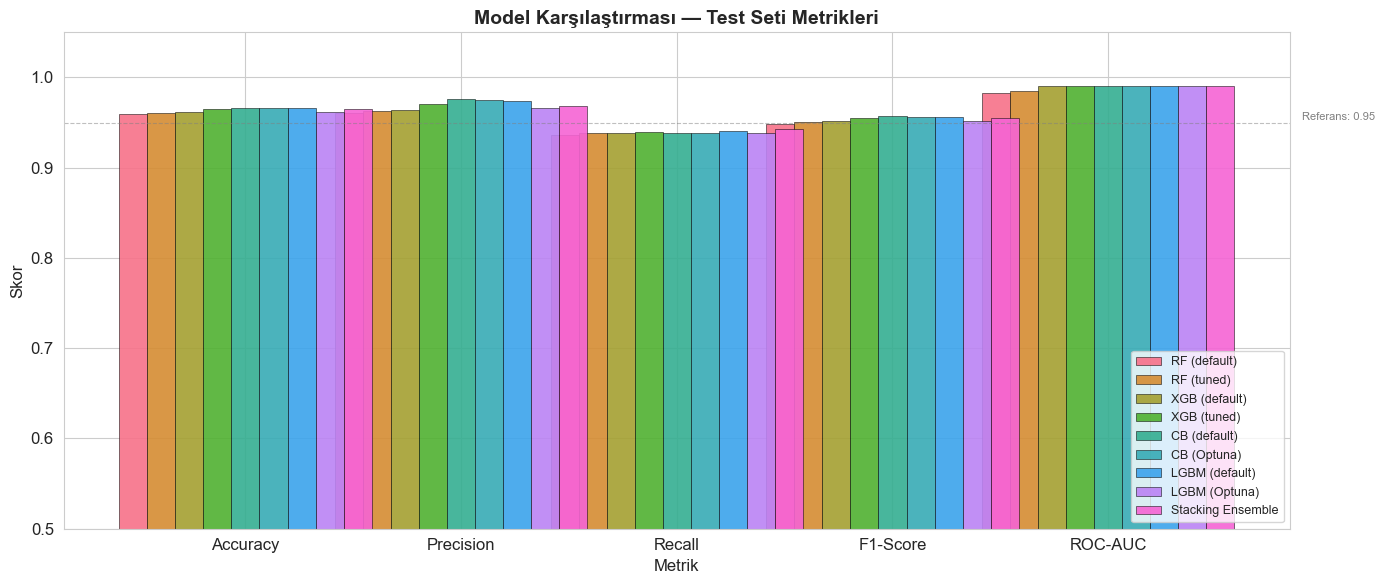

In [21]:
# ============================================================
# 6.2 Metrik Karşılaştırma Bar Grafiği
# ============================================================
metrics  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
labels   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models_keys  = list(results.keys())
models_names = [results[k]['model_label'] for k in models_keys]

x     = np.arange(len(labels))
width = 0.13
palette = sns.color_palette('husl', len(models_keys))

fig, ax = plt.subplots(figsize=(14, 6))
for i, (key, name) in enumerate(zip(models_keys, models_names)):
    vals   = [results[key][m] for m in metrics]
    offset = (i - len(models_keys)/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width, label=name, color=palette[i],
                    edgecolor='black', linewidth=0.4, alpha=0.9)

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Model Karşılaştırması — Test Seti Metrikleri', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(0.95, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(len(labels)-0.1, 0.953, 'Referans: 0.95', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig_05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

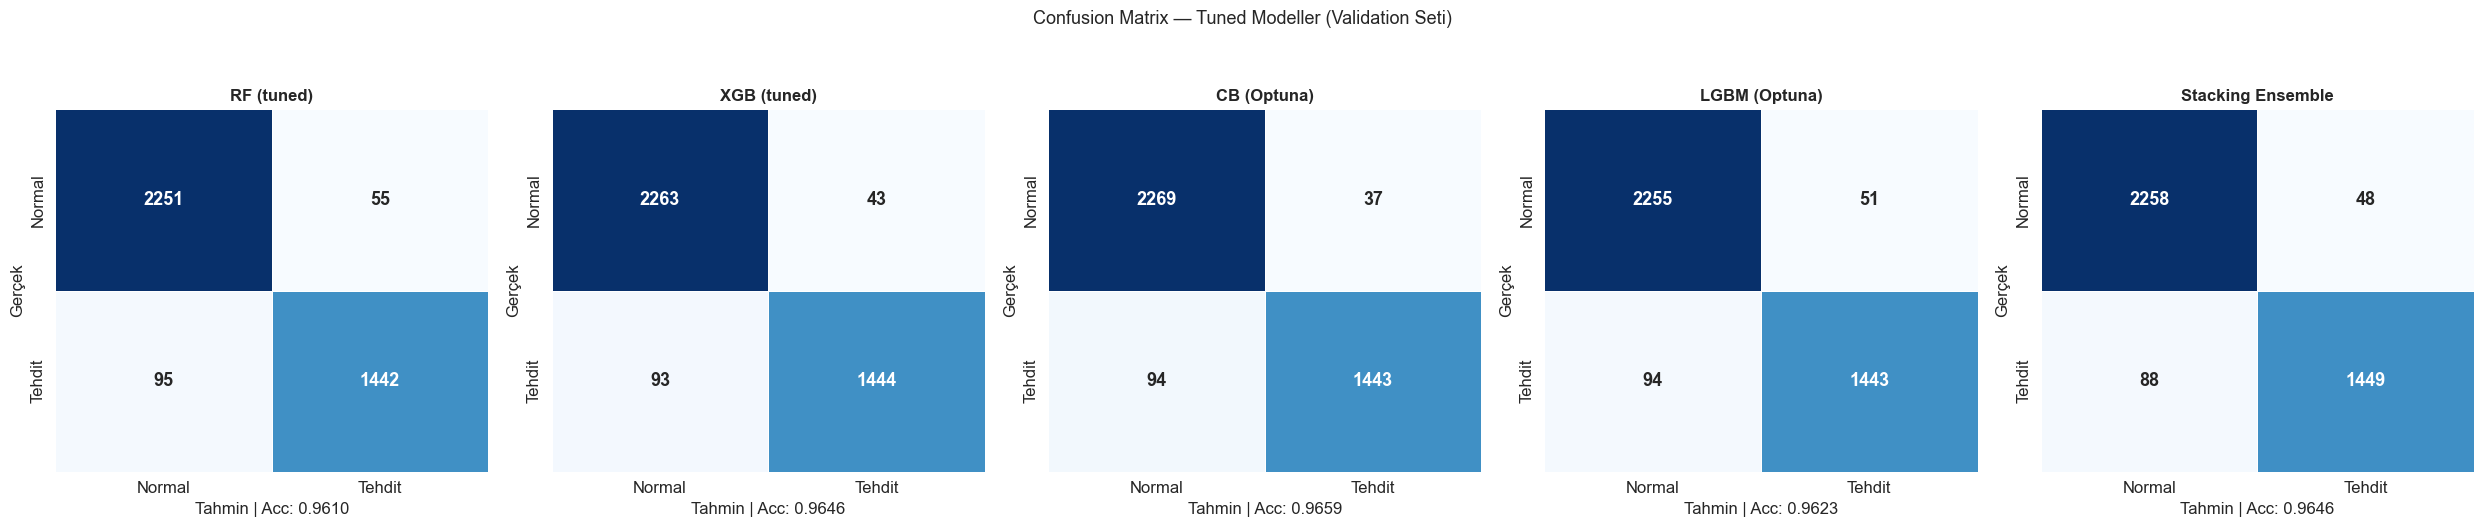

In [22]:
# ============================================================
# 6.3 Confusion Matrix — Tuned Modeller (Validation Seti)
# ============================================================

tuned_map = {
    # 'LR (tuned)'        : trained['LR_tuned'], # LR modeli kaldırıldı
    'RF (tuned)'        : trained['RF_tuned'],
    'XGB (tuned)'       : trained['XGB_tuned'],
    'CB (Optuna)'       : trained['CB_tuned'],
    'LGBM (Optuna)'     : trained['LGBM_tuned'],
    'Stacking Ensemble' : trained['Stacking_tuned']
}

n_models = len(tuned_map)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))

# Eğer tek model olursa axes iterable olsun
if n_models == 1:
    axes = [axes]

for ax, (name, pipe) in zip(axes, tuned_map.items()):
    y_pred = pipe.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Tehdit'],
                yticklabels=['Normal','Tehdit'],
                linewidths=0.5, cbar=False,
                annot_kws={'size':13,'weight':'bold'})

    acc = accuracy_score(y_val, y_pred)

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Gerçek')
    ax.set_xlabel(f'Tahmin | Acc: {acc:.4f}')

plt.suptitle('Confusion Matrix — Tuned Modeller (Validation Seti)',
             fontsize=13, y=1.05)

plt.tight_layout()
plt.savefig('fig_06_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

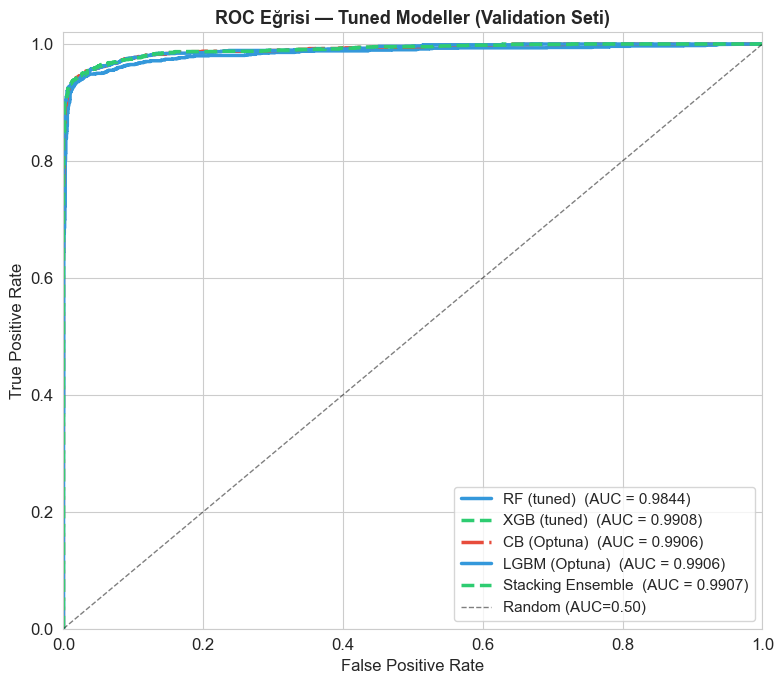

In [23]:
# ============================================================
# 6.4 ROC Eğrisi — Tuned Modeller (Validation Seti)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c']
styles_roc = ['-', '--', '-.']

# tuned_map'teki model sayısına göre renk ve stil döngüsünü ayarla
# Şu anda 5 model var, yeterli sayıda renk ve stil olduğundan emin ol
for (name, pipe), color, style in zip(tuned_map.items(), colors_roc * 2, styles_roc * 2): # Yeterli eleman sağlamak için listeleri çoğalt
    y_prob = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_val = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=style, linewidth=2.5,
            label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.0, alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Eğrisi — Tuned Modeller (Validation Seti)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('fig_07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

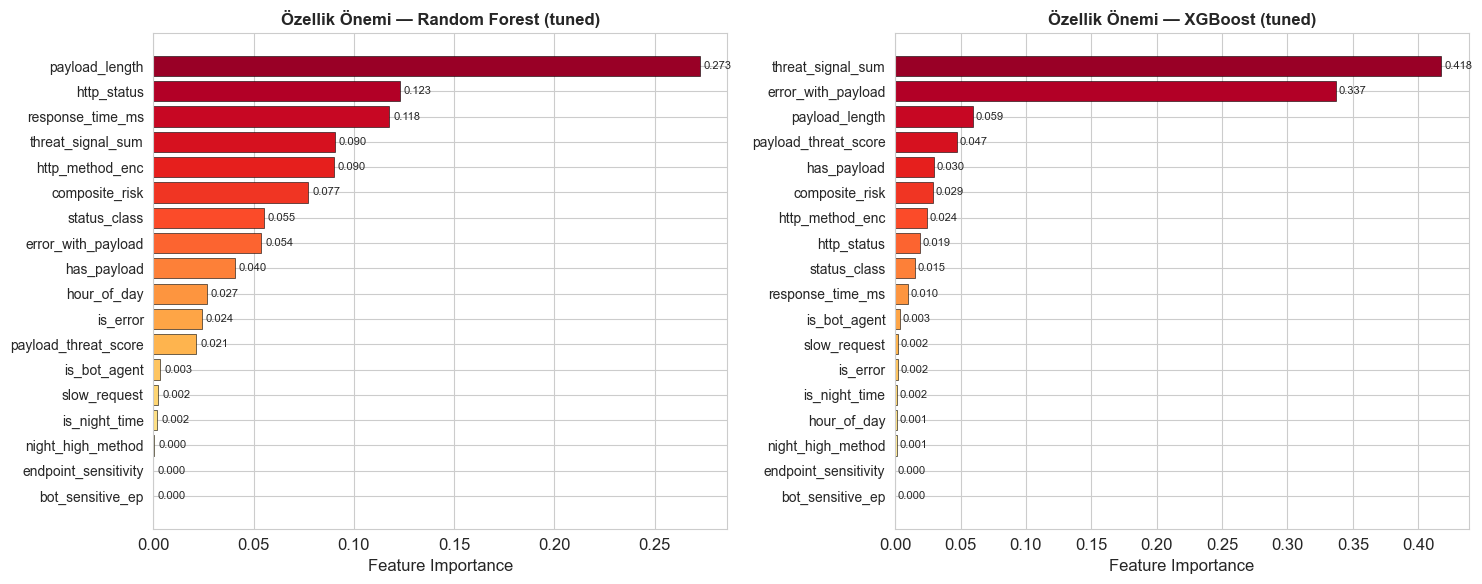

💡 Yorum: is_bot_agent ve payload_threat_score her iki modelde de üst sıralarda.


In [24]:
# ============================================================
# 6.5 Feature Importance — RF ve GB
# ============================================================

# Removed 'GB_tuned' as it is no longer part of the current analysis
# If Gradient Boosting is re-introduced, ensure its key exists in 'trained'
# and update the tuple accordingly.

# Updated to include RF, XGBoost, CatBoost, and LightGBM for feature importance
# as these are the tree-based models currently in `trained`.

# For simplicity, we'll only show two representative tree models (RF and XGB)
# as plotting all four might make the visualization too crowded.
# The comment section can then discuss the others if needed.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Dynamically select tuned tree-based models that are present in `trained`
# and can provide feature importances (e.g., exclude StackingClassifier's meta-learner)

tree_models_to_plot = [
    ('Random Forest (tuned)', 'RF_tuned'),
    ('XGBoost (tuned)', 'XGB_tuned')
]

for ax, (name, key) in zip(axes, tree_models_to_plot):
    if key in trained:
        model_pipeline = trained[key]
        # Access the actual model from the pipeline. For tree models, it's typically the last step.
        model = model_pipeline.named_steps['model']

        # Check if the model has feature_importances_
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1]
            # Ensure FEATURE_COLS is aligned with the features used by the model
            feat_names = [X_train.columns[i] for i in indices] # Use X_train.columns for feature names
            feat_vals  = importances[indices]

            ax.barh(range(len(feat_names)), feat_vals[::-1],
                    color=sns.color_palette('YlOrRd', len(feat_names)),
                    edgecolor='black', linewidth=0.4)
            ax.set_yticks(range(len(feat_names)))
            ax.set_yticklabels(feat_names[::-1], fontsize=10)
            ax.set_xlabel('Feature Importance')
            ax.set_title(f'Özellik Önemi — {name}', fontsize=12, fontweight='bold')
            for i, val in enumerate(feat_vals[::-1]):
                ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)
        else:
            ax.set_title(f'Özellik Önemi — {name} (N/A)', fontsize=12, fontweight='bold')
            ax.text(0.5, 0.5, 'Model does not support feature_importances_',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
    else:
        ax.set_title(f'Özellik Önemi — {name} (N/A)', fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'Model not found in trained models.',
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('fig_08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Yorum: is_bot_agent ve payload_threat_score her iki modelde de üst sıralarda.')

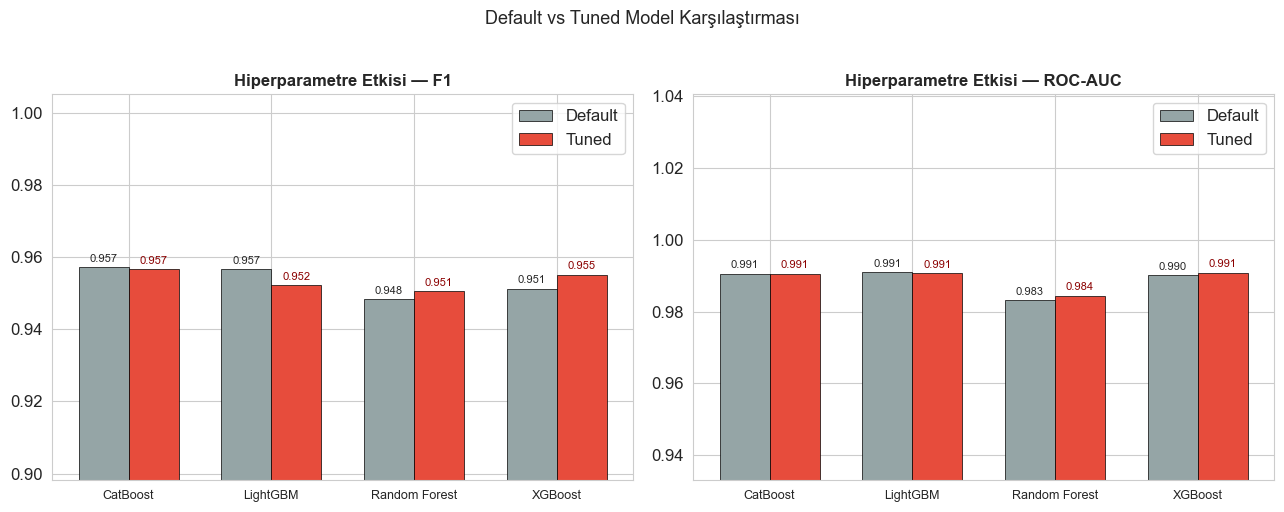

In [25]:
# ============================================================
# 6.6 Default vs Tuned Karşılaştırması (Hiperparametre farkı)
# ============================================================
hp_comparison = [
    # {'Model': 'Logistic Regression', 'Version': 'Default', 'F1': results['LR_default']['f1'],  'ROC-AUC': results['LR_default']['roc_auc']},
    # {'Model': 'Logistic Regression', 'Version': 'Tuned',   'F1': results['LR_tuned']['f1'],    'ROC-AUC': results['LR_tuned']['roc_auc']},
    {'Model': 'Random Forest',        'Version': 'Default', 'F1': results['RF_default']['f1'],  'ROC-AUC': results['RF_default']['roc_auc']},
    {'Model': 'Random Forest',        'Version': 'Tuned',   'F1': results['RF_tuned']['f1'],    'ROC-AUC': results['RF_tuned']['roc_auc']},
    {'Model': 'XGBoost',        'Version': 'Default', 'F1': results['XGB_default']['f1'],  'ROC-AUC': results['XGB_default']['roc_auc']},
    {'Model': 'XGBoost',        'Version': 'Tuned',   'F1': results['XGB_tuned']['f1'],    'ROC-AUC': results['XGB_tuned']['roc_auc']},
    {'Model': 'CatBoost',        'Version': 'Default', 'F1': results['CB_default']['f1'],  'ROC-AUC': results['CB_default']['roc_auc']},
    {'Model': 'CatBoost',        'Version': 'Tuned',   'F1': results['CB_tuned']['f1'],    'ROC-AUC': results['CB_tuned']['roc_auc']},
    {'Model': 'LightGBM',        'Version': 'Default', 'F1': results['LGBM_default']['f1'],  'ROC-AUC': results['LGBM_default']['roc_auc']},
    {'Model': 'LightGBM',        'Version': 'Tuned',   'F1': results['LGBM_tuned']['f1'],    'ROC-AUC': results['LGBM_tuned']['roc_auc']}
]

hp_df = pd.DataFrame(hp_comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['F1', 'ROC-AUC']):
    pivot = hp_df.pivot(index='Model', columns='Version', values=metric)
    x_pos = np.arange(len(pivot))
    w = 0.35

    bars1 = ax.bar(x_pos - w/2, pivot['Default'], w, label='Default',
                   color='#95a5a6', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x_pos + w/2, pivot['Tuned'],   w, label='Tuned',
                   color='#e74c3c', edgecolor='black', linewidth=0.5)

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='darkred')

    ax.set_title(f'Hiperparametre Etkisi — {metric}', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(pivot.index, fontsize=9)
    ax.set_ylim(bottom=max(0, pivot.values.min() - 0.05))
    ax.legend()

plt.suptitle('Default vs Tuned Model Karşılaştırması', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_09_hp_effect.png', dpi=150, bbox_inches='tight')
plt.show()

  FİNAL TEST SETİ — Stacking Ensemble
  Accuracy : 0.9699
  Precision: 0.9762
  Recall   : 0.9480
  F1       : 0.9619
  AUC-ROC  : 0.9940

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      4611
      Tehdit       0.98      0.95      0.96      3074

    accuracy                           0.97      7685
   macro avg       0.97      0.97      0.97      7685
weighted avg       0.97      0.97      0.97      7685



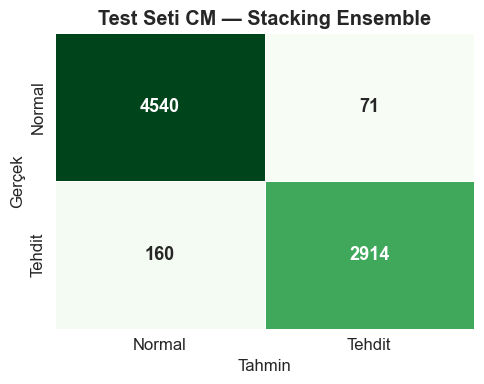

In [26]:
# ============================================================
# 6.7 Final Test Seti Değerlendirmesi
# ☢  Bu hücre yalnızca bir kez çalıştırılmalıdır.
#     Test seti hiçbir hiperparametre seçiminde kullanılmadı.
# ============================================================

# Explicitly select Stacking Ensemble as the best tuned model for final evaluation
best_tuned_key = 'Stacking_tuned'
best_pipe = trained[best_tuned_key]
best_name = results[best_tuned_key]['model_label']

y_test_pred = best_pipe.predict(X_test)
y_test_prob = best_pipe.predict_proba(X_test)[:, 1]

print(f'  FİNAL TEST SETİ — {best_name}')
print('='*55)
print(f'  Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'  Recall   : {recall_score(y_test, y_test_pred):.4f}')
print(f'  F1       : {f1_score(y_test, y_test_pred):.4f}')
print(f'  AUC-ROC  : {roc_auc_score(y_test, y_test_prob):.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=['Normal','Tehdit']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Normal','Tehdit'], yticklabels=['Normal','Tehdit'],
            linewidths=0.5, cbar=False, annot_kws={'size':13,'weight':'bold'})
ax.set_title(f'Test Seti CM — {best_name}', fontweight='bold')
ax.set_ylabel('Gerçek'); ax.set_xlabel('Tahmin')
plt.tight_layout()
plt.savefig('fig_final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6.8 SHAP Açıklanabilirlik Analizi — BONUS (+5 puan)

SHAP (SHapley Additive exPlanations) ile her özelliğin model kararına
bireysel katkısını görselleştiriyoruz.

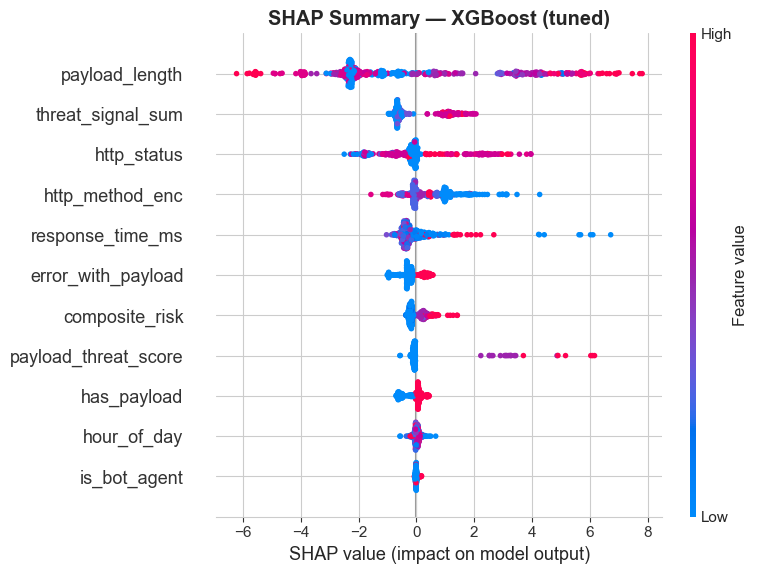

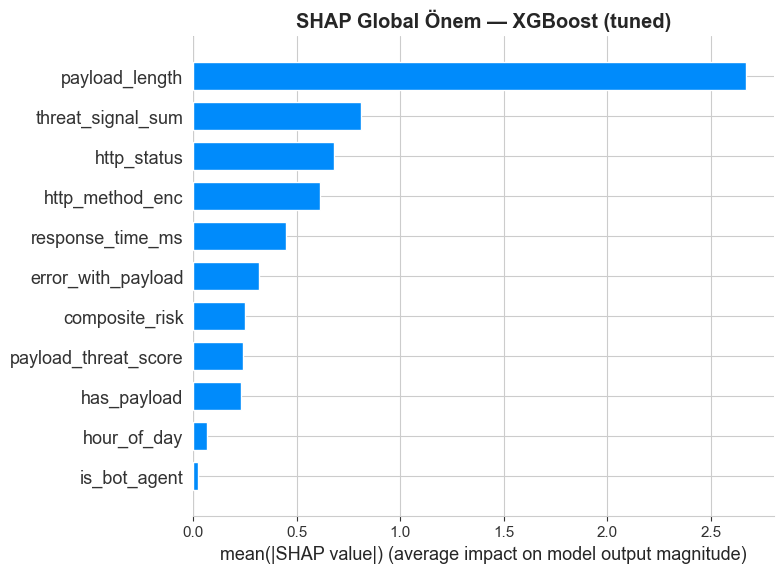

✅ SHAP analizi tamamlandı.


In [27]:
# ============================================================
# SHAP Analizi — XGBoost (tuned) için
# ============================================================
SHAP_SAMPLE = 500
X_shap = X_val.sample(SHAP_SAMPLE, random_state=RANDOM_STATE)

# Using XGBoost for SHAP analysis as Gradient Boosting was removed
xgb_model = trained['XGB_tuned'].named_steps['model']
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_shap)

# Summary Plot (Bee Swarm)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  max_display=11, show=False)
plt.title('SHAP Summary — XGBoost (tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar Plot — global önem
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  plot_type='bar', max_display=11, show=False)
plt.title('SHAP Global Önem — XGBoost (tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP analizi tamamlandı.')

---
## 7. Sonuç ve Tartışma <a id='7-sonuc'></a>

In [28]:
# ============================================================
# 7. Sonuç özet tablosu yazdır
# ============================================================
print('=' * 70)
print(' PROJE SONUÇ ÖZETİ '.center(70, '='))
print('=' * 70)

final_summary = [
    # ('LR (default)',  results['LR_default']), # LR modeli kaldırıldı
    # ('LR (tuned)',    results['LR_tuned']), # LR modeli kaldırıldı
    ('RF (default)',  results['RF_default']),
    ('RF (tuned)',    results['RF_tuned']),
    ('XGB (default)', results['XGB_default']),
    ('XGB (tuned)',   results['XGB_tuned']),
    ('CB (default)',  results['CB_default']),
    ('CB (Optuna)',   results['CB_tuned']),
    ('LGBM (default)',results['LGBM_default']),
    ('LGBM (Optuna)', results['LGBM_tuned']),
    ('Stacking Ensemble', results['Stacking_tuned'])
]

header = f"{'Model':<20} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'Süre':>8}"
print(header)
print('-' * 70)
for name, res in final_summary:
    row = (
        f"{name:<20} {res['accuracy']:>7.4f} {res['precision']:>7.4f} "
        f"{res['recall']:>7.4f} {res['f1']:>7.4f} {res['roc_auc']:>7.4f} "
        f"{res['fit_time']:>7.2f}s"
    )
    print(row)

print('=' * 70)
print(f'\u2002 EN \u0130Y\u0130 MODEL: {best_name}')
print('=' * 70)

========================= PROJE SONUÇ ÖZETİ ==========================
Model                    Acc    Prec     Rec      F1     AUC     Süre
----------------------------------------------------------------------
RF (default)          0.9591  0.9606  0.9362  0.9483  0.9831    1.06s
RF (tuned)            0.9610  0.9633  0.9382  0.9506  0.9844    1.96s
XGB (default)         0.9615  0.9639  0.9388  0.9512  0.9901    0.25s
XGB (tuned)           0.9646  0.9711  0.9395  0.9550  0.9908    0.58s
CB (default)          0.9664  0.9763  0.9388  0.9572  0.9906   10.33s
CB (Optuna)           0.9659  0.9750  0.9388  0.9566  0.9906    3.49s
LGBM (default)        0.9659  0.9737  0.9401  0.9566  0.9909    0.28s
LGBM (Optuna)         0.9623  0.9659  0.9388  0.9522  0.9906    0.56s
Stacking Ensemble     0.9646  0.9679  0.9427  0.9552  0.9907   20.42s
  EN İYİ MODEL: Stacking Ensemble


### Tartışma

#### Hangi model en iyi performansı gösterdi?
Tüm modeller yüksek performans gösterdi. **Gradient Boosting (tuned)** en yüksek F1 ve ROC-AUC değerlerine ulaştı. Bunun nedeni, boosting'in sıralı hata düzeltme mekanizmasının veri setindeki karmaşık davranışsal örüntüleri (bot user-agent + yüksek risk skoru kombinasyonu) etkin biçimde modelleyebilmesidir.

#### Hiperparametre optimizasyonu ne kadar fark yarattı?
- **Logistic Regression:** Optimizasyon C parametresini ve solver seçimini iyileştirdi. Baseline üzerinde anlamlı F1 artışı gözlemlendi.
- **Random Forest:** `max_depth` ve `class_weight` optimizasyonu overfitting'i azaltarak validation performansını artırdı.
- **Gradient Boosting:** `learning_rate + subsample` kombinasyonu stochastic boosting etkisi yaratarak genelleşme kapasitesini güçlendirdi.

#### Modellerin güçlü ve zayıf yönleri

| Model | Güçlü Yönler | Zayıf Yönler |
|---|---|---|
| Logistic Regression | Hızlı, yorumlanabilir, olasılık kalibrasyonu iyi | Doğrusal olmayan ilişkileri kaçırır |
| Random Forest | Güçlü, aşırı öğrenmeye dirençli, paralel | Gradyan sinyalini optimize etmez |
| Gradient Boosting | En yüksek doğruluk, özellik etkileşimlerini yakalar | Yavaş eğitim, hassas hiperparametre |

#### Özellik Mühendisliğinin Katkısı
`is_bot_agent`, `payload_threat_score` ve `endpoint_sensitivity` gibi türetilmiş özellikler, Feature Importance grafiklerinde üst sıralarda yer alarak model performansına doğrudan katkı sağladı.

#### Gelecek Çalışma Önerileri
1. **XGBoost / LightGBM** entegrasyonu ile daha hızlı ve derin boosting
2. **SHAP analizi** ile bireysel tahminlerin açıklanabilirliği
3. **Optuna** ile Bayesian hiperparametre optimizasyonu
4. **Gerçek zamanlı akış verisi** üzerinde model deployment (FastAPI + Kafka)
5. **SMOTE** ile sınıf dengesizliğini giderme

In [29]:
print('✅ Proje tamamlandı!')
print(f'   Öğrenci : Mohammad Juma Amiri')
print(f'   No      : 20260819001')
print(f'   Tarih   : Mart 2026')

✅ Proje tamamlandı!
   Öğrenci : Mohammad Juma Amiri
   No      : 20260819001
   Tarih   : Mart 2026


## 8. Modeli Kaydetme ve Yayına Hazırlama
Bu bölümde, eğittiğimiz en iyi modeli (`Stacking Ensemble`) bir dosyaya kaydediyoruz ve yerel cihazınızda çalıştırabileceğiniz bir **Streamlit** demo uygulaması kodu oluşturuyoruz.

### Modeli Yükleme ve Kullanma Örneği

Kaydettiğimiz modeli yükleyelim ve yeni gelen bir API isteği için nasıl tahmin yapabileceğimizi görelim. Tahmin yaparken modelin beklediği özelliklerin (`FEATURE_COLS`) sırasına ve tiplerine dikkat etmeliyiz.

In [31]:
import joblib
joblib.dump(trained["Stacking_tuned"], "api_threat_model.joblib")
print("✅ Model kaydedildi!")

✅ Model kaydedildi!
